## $\color{red}{\text{REPORT no 2 }}$

---

#### We aimed to reproduce every plot from the paper and to get to similar conclusions.

In [188]:
from sunpy.net import Fido, attrs as a
from sunpy.map import Map
import sunpy.map
import sunpy_soar
from stixpy.net.client import STIXClient  
from datetime import datetime
from sunpy.timeseries import TimeSeries
from stixpy.timeseries import quicklook 
from stixpy.product import Product
from stixpy.timeseries.quicklook import QLLightCurve
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as pltc
from matplotlib.patches import Rectangle
import matplotlib.animation as animation
import pandas as pd
import numpy as np
from numba import jit
import glob
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
import os
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

### $\color{red}{\text{1.1. STIX}} $

In [80]:
stix_data = Fido.search(a.Time("2024-10-15", "2024-10-15"), a.Instrument.stix, a.stix.DataProduct.ql_lightcurve)

In [81]:
stix = Fido.fetch(stix_data)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

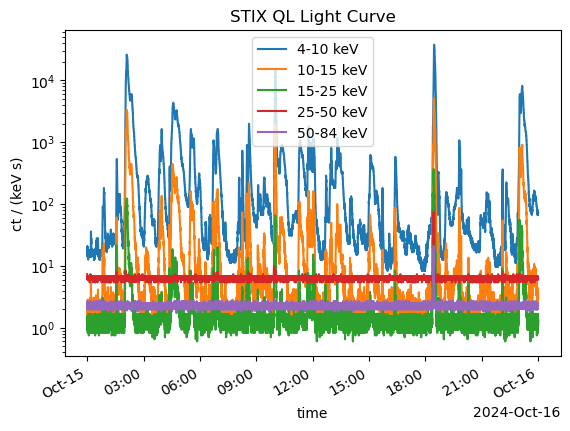

In [114]:
stix_lcs = TimeSeries(stix)
stix_lcs.peek()

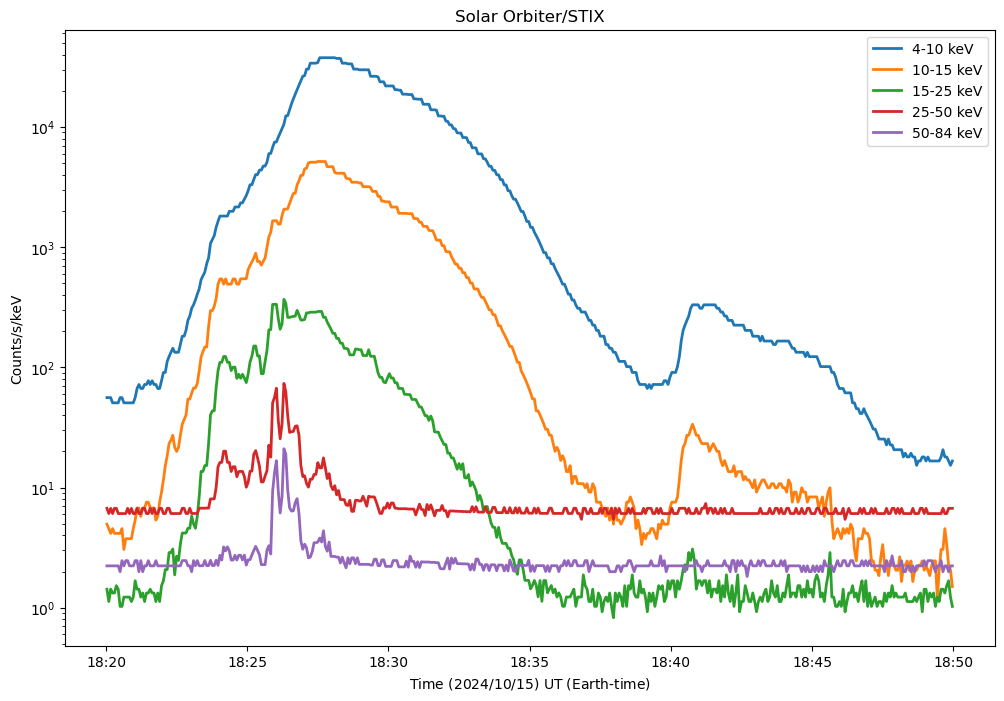

In [116]:
stix_lcs = TimeSeries(stix)
stix_lcs = stix_lcs.to_dataframe().truncate("2024-10-15 18:20", "2024-10-15 18:50")

fig, ax = plt.subplots(figsize=(12, 8))
energy_bands = ['4-10 keV', '10-15 keV', '15-25 keV', '25-50 keV', '50-84 keV']

for band in energy_bands:
    plt.plot(stix_lcs.index, stix_lcs[band], label=band, linewidth=2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

plt.xlabel(r'Time $(2024/10/15)$ UT (Earth-time)')
plt.ylabel(r'Counts/s/keV')
plt.yscale('log')
plt.title('Solar Orbiter/STIX')
plt.legend()
plt.show()

### $\color{red}{\text{1.2. Compressed Pixel  Data (CPD) from STIX}} $

---

#### This type of files gives us higher time resolution (potentially sub-second), more energy 

#### bins/flexibility and excellent opportunity for detailed QPP analysis. However, issue is 

#### that STIX science data files don't always align perfectly with our requested time range.

In [84]:
sci_query = Fido.search(a.Time("2024-10-15 18:00", "2024-10-15 19:00"), a.Instrument.stix, a.stix.DataType.sci)
print(sci_query)

Results from 1 Provider:

6 Results from the STIXClient:

       Start Time               End Time        Instrument Level DataType  DataProduct  Ver Request ID
----------------------- ----------------------- ---------- ----- -------- ------------- --- ----------
2024-10-15 12:00:00.000 2024-10-15 18:00:04.000       STIX    L1      SCI  sci-xray-cpd V02 2410155003
2024-10-15 18:00:04.000 2024-10-16 00:00:02.000       STIX    L1      SCI  sci-xray-cpd V02 2410152837
2024-10-15 18:16:50.000 2024-10-15 18:39:28.000       STIX    L1      SCI  sci-xray-cpd V02 2410155856
2024-10-15 18:16:57.000 2024-10-15 18:51:33.000       STIX    L1      SCI  sci-xray-cpd V02 2410156916
2024-10-15 16:45:07.000 2024-10-15 22:50:01.000       STIX    L1      SCI sci-xray-spec V02 2410153003
2024-10-15 16:45:07.000 2024-10-15 22:50:01.000       STIX    L1      SCI sci-xray-spec V04 2410153003




In [85]:
cpd_i = [] # exctraction of appropriate CPDs
for i, result in enumerate(sci_query[0]):
    if 'cpd' in result['DataProduct']:
        print(f"CPD file {i}: {result['Start Time']} to {result['End Time']}")
        cpd_i.append(i)

CPD file 0: 2024-10-15 12:00:00.000 to 2024-10-15 18:00:04.000
CPD file 1: 2024-10-15 18:00:04.000 to 2024-10-16 00:00:02.000
CPD file 2: 2024-10-15 18:16:50.000 to 2024-10-15 18:39:28.000
CPD file 3: 2024-10-15 18:16:57.000 to 2024-10-15 18:51:33.000


In [86]:
relevant_files = [i for i in cpd_i if i in [1, 2, 3]]  # further adjustement
sci_files = Fido.fetch(sci_query[0][relevant_files])
cpd_products = []
for file in sci_files:
    if 'cpd' in str(file):
        cpd_products.append(Product(file))

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

In [152]:
cpd_flare = cpd_products[2]
print("Shapes:") # closer examination of the data structure
print(f"Time: {cpd_flare.data['time'].shape}")
print(f"Counts: {cpd_flare.data['counts'].shape}")
print(f"Detector masks: {cpd_flare.detector_masks}")

time_stix = cpd_flare.data['time']
# time_mpl = time.plot_date
time_res = (time_stix[1] - time_stix[0]).to('s').value
print(f"Time resolution: ~{time_res:.1f} s")
time_stix = time_stix.datetime

Shapes:
Time: (562,)
Counts: (562, 32, 8, 32)
Detector masks: DetectorMasks
    [0...561]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

Time resolution: ~7.0 s


In [158]:
def create_stix_energy_bands(lcs, time_stix):
    energy_bands = {
        '4-15 keV': np.sum(lcs[:, 0:11], axis=1), 
        '15-25 keV': np.sum(lcs[:, 11:16], axis=1), 
        '25-50 keV': np.sum(lcs[:, 16:17], axis=1), 
        '50-100 keV': np.sum(lcs[:, 17:23], axis=1), 
        '4-50 keV': np.sum(lcs[:, 0:17], axis=1), 
        '25-100 keV': np.sum(lcs[:, 16:23], axis=1)}
    
    stix_lightcurves = {}
    for band_name, counts in energy_bands.items():
        stix_lightcurves[band_name] = pd.Series(counts, index=pd.DatetimeIndex(time_stix), name=band_name)
    return stix_lightcurves

stix_lcs = create_stix_energy_bands(lcs, time_stix)

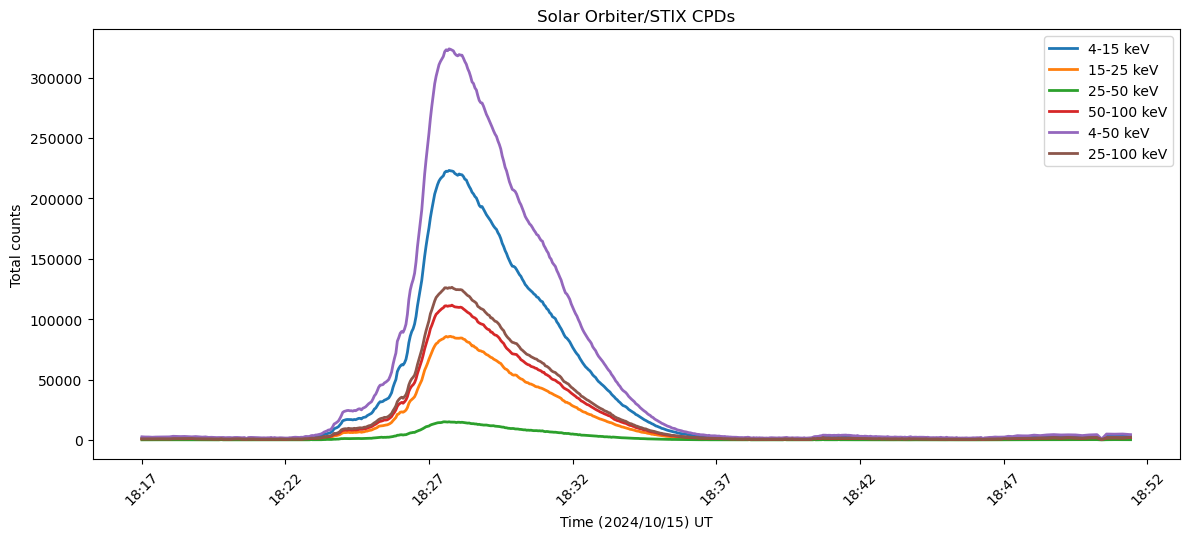

In [162]:
plt.figure(figsize=(12,5.5))
for band_name, lc in stix_lcs.items():
    plt.plot(lc.index, lc.values, label=band_name, linewidth=2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xticks(rotation=45)
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Total counts')
plt.title('Solar Orbiter/STIX CPDs')
plt.legend()
plt.tight_layout()
plt.show()

### $\color{red}{\text{2. Soft X-ray (SXR) light curve from GOES}} $

---

In [92]:
res = Fido.search(a.Time("2024-10-15 18:00:00", "2024-10-15 19:00:00"), a.Instrument('XRS'))

In [93]:
files = Fido.fetch(res)
goes = TimeSeries(files)

Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

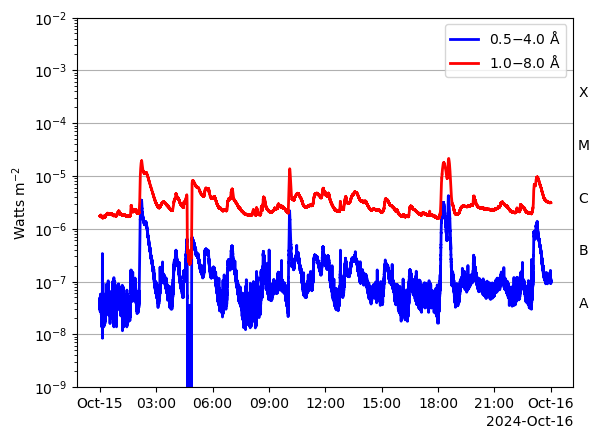

In [94]:
fig, ax = plt.subplots() # retrieval not really okay regarding time range, but we can fix that
goes[0].plot(axes=ax) # we've obtained four datasets
plt.show()

In [95]:
goes_data = goes[0].to_dataframe() 
goes_flare = goes_data.truncate("2024-10-15 18:00:00", "2024-10-15 20:30:00")

print(f"Peak XRSB flux: {goes_flare['xrsb'].max():.2e} W/m²")
print(f"Peak XRSA flux: {goes_flare['xrsa'].max():.2e} W/m²")

xrsb_peak = goes_flare['xrsb'].max() # some sort of flare classification
if 1e-5 <= xrsb_peak < 1e-4:
    flare_class = f"M{xrsb_peak/1e-5:.1f}"
    print(f"Flare classification: {flare_class}")

Peak XRSB flux: 2.14e-05 W/m²
Peak XRSA flux: 4.23e-06 W/m²
Flare classification: M2.1


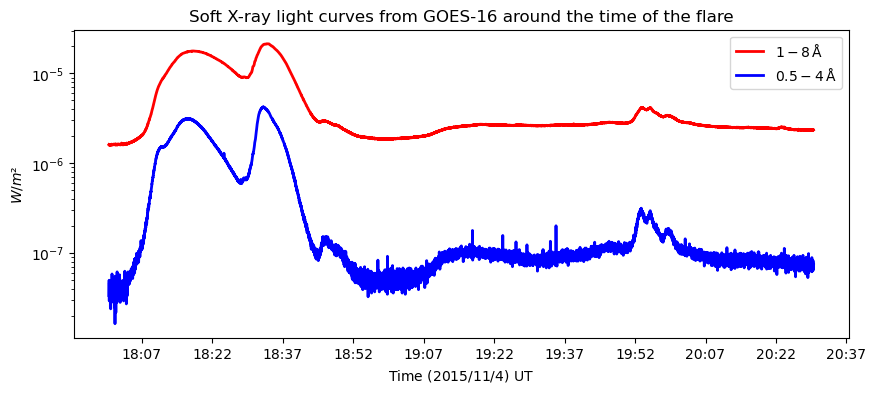

In [96]:
plt.figure(figsize=(10,4))
plt.plot(goes_flare.index, goes_flare['xrsb'], 'r-', label=r'$1-8\,\rm\AA$', linewidth=2)
plt.plot(goes_flare.index, goes_flare['xrsa'], 'b-', label=r'$0.5-4\,\rm\AA$', linewidth=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
plt.yscale('log')
plt.ylabel(r'$W/m²$')
plt.xlabel(r'Time $(2015/11/4)$ UT')
plt.title('Soft X-ray light curves from GOES-16 around the time of the flare')
plt.legend()
plt.show()

#### For our QPP analysis, we'll use XRSB (1-8 Å) because it is what defines the M-class rating.

#### Also, it has better signal-to-noise ratio, broader energy range (which overlaps with STIX

#### lower energy bands). 

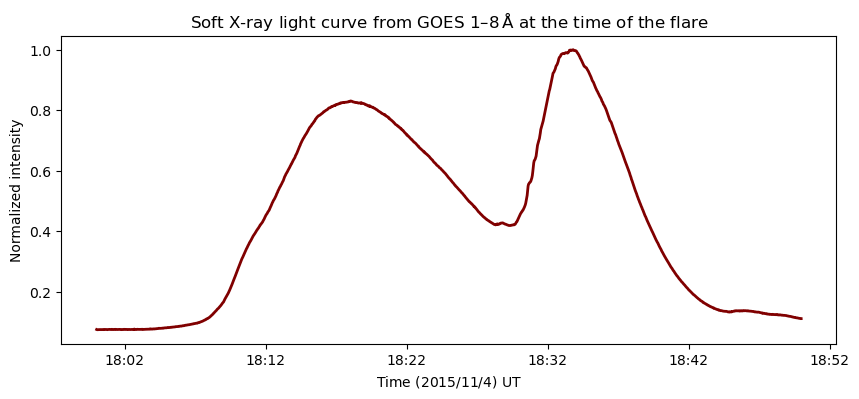

In [97]:
goes_df = goes[0].to_dataframe().truncate("2024-10-15 18:00:00","2024-10-15 18:50:00")
goes_df = goes_df.resample('2s').mean()
intensity = goes_df['xrsb']
norm_intensity = intensity / intensity.max()

plt.figure(figsize=(10,4))
plt.plot(norm_intensity.index, norm_intensity, c='maroon', lw=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
plt.xlabel(r'Time $(2015/11/4)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Soft X-ray light curve from GOES $1–8\,\rm\AA$ at the time of the flare')
plt.show()

#### Because we want to show Neupert effect later, we'll calculate SXR derivative.

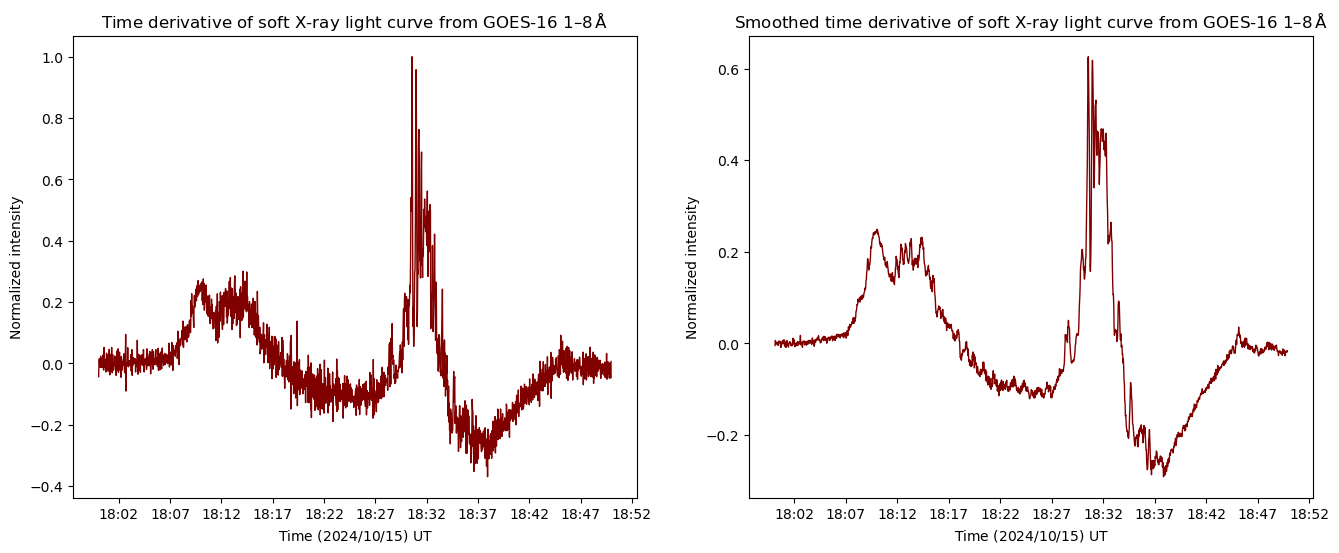

In [98]:
dt = norm_intensity.index.to_series().diff().dt.total_seconds()
dint_dt = norm_intensity.diff()/dt
dint_dt = dint_dt.dropna()
dint_dt_norm = dint_dt / dint_dt.max()
# dint_dt_norm = (dint_dt - dint_dt.min())/(dint_dt.max() - dint_dt.min())

smooth_window = int(12 / 2)  # smoothing
smooth_goes_derv = dint_dt_norm.rolling(window=smooth_window, center=True).mean().dropna()

plt.figure(figsize=(16,6))
plt.subplot(121)
plt.plot(dint_dt_norm, c='maroon', lw=1)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Time derivative of soft X-ray light curve from GOES-16 $1–8\,\rm\AA$')

plt.subplot(122)
plt.plot(smooth_goes_derv, c='maroon', lw=1)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Smoothed time derivative of soft X-ray light curve from GOES-16 $1–8\,\rm\AA$')
plt.show()

### $\color{red}{\text{3. Hard X-ray (HXR) light curve from Fermi GBM}} $

---

In [99]:
res = Fido.search(a.Time("2024-10-15 18:00", "2024-10-15 19:00"), a.Instrument('GBM'), a.Source('FERMI'), a.Detector('N5'), a.Physobs('flux'))

In [100]:
files = Fido.fetch(res)
gbm = TimeSeries(files, concatenate=True)

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [101]:
print(gbm.columns)

gbm_df = gbm.to_dataframe()
print(f"Original GBM time range: {gbm_df.index[0]} to {gbm_df.index[-1]}")
print(f"Original time resolution: {(gbm_df.index[1] - gbm_df.index[0]).total_seconds():.3f} seconds")

['4-15 keV', '15-25 keV', '25-50 keV', '50-100 keV', '100-300 keV', '300-800 keV', '800-2000 keV']
Original GBM time range: 2024-10-14 23:59:52.619436145 to 2024-10-15 23:59:59.955803990
Original time resolution: 4.096 seconds


In [102]:
gbm_df = gbm.to_dataframe()
gbm_df = gbm_df.truncate("2024-10-15 18:00:00","2024-10-15 19:00:00")
gbm_r = gbm_df.resample('1600ms').mean().dropna() # resampling

dt = gbm_r.index.to_series().diff().dt.total_seconds().dropna()
print("Check: new median delta t(s)= ", dt.median())

# norm_gbm = (gbm_r - gbm_r.min()) / (gbm_r.max() - gbm_r.min())
# smooth_window = int(5 / 1.6)  # smoothing
# smooth_gbm = norm_gbm.rolling(window=smooth_window, center=True).mean().dropna()
# with open('fermi_gbm.pkl', 'wb') as fout:
#     pickle.dump(smooth_gbm, fout)

Check: new median delta t(s)=  1.6


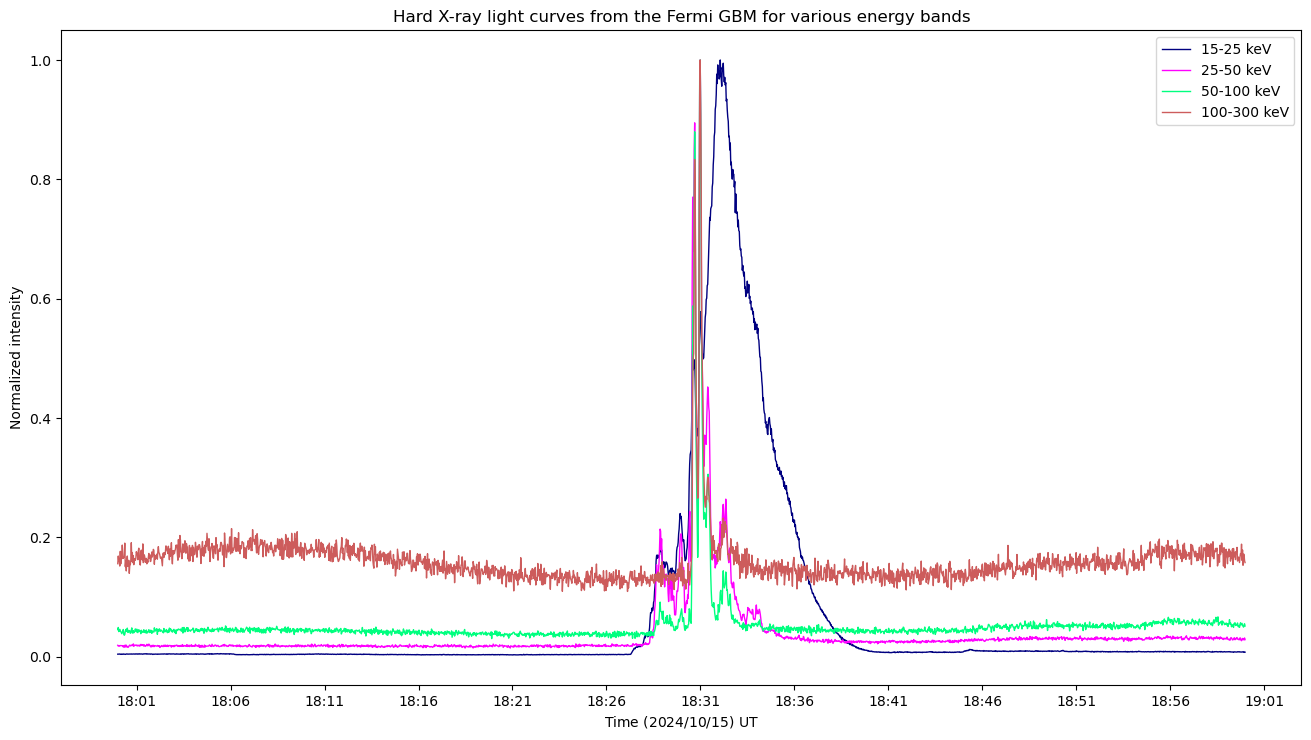

In [103]:
energy_bands = ['15-25 keV', '25-50 keV', '50-100 keV', '100-300 keV']

plt.figure(figsize=(16,8.5))
colors = ['navy', 'magenta', 'springgreen', 'indianred']

for i, band in enumerate(energy_bands):
    gbm_band = gbm_r[band]
    norm_gbm_band = gbm_band / gbm_band.max()
    plt.plot(norm_gbm_band.index, norm_gbm_band, color=colors[i], label=f'{band}', linewidth=1)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Hard X-ray light curves from the Fermi GBM for various energy bands')
plt.legend()
plt.show()

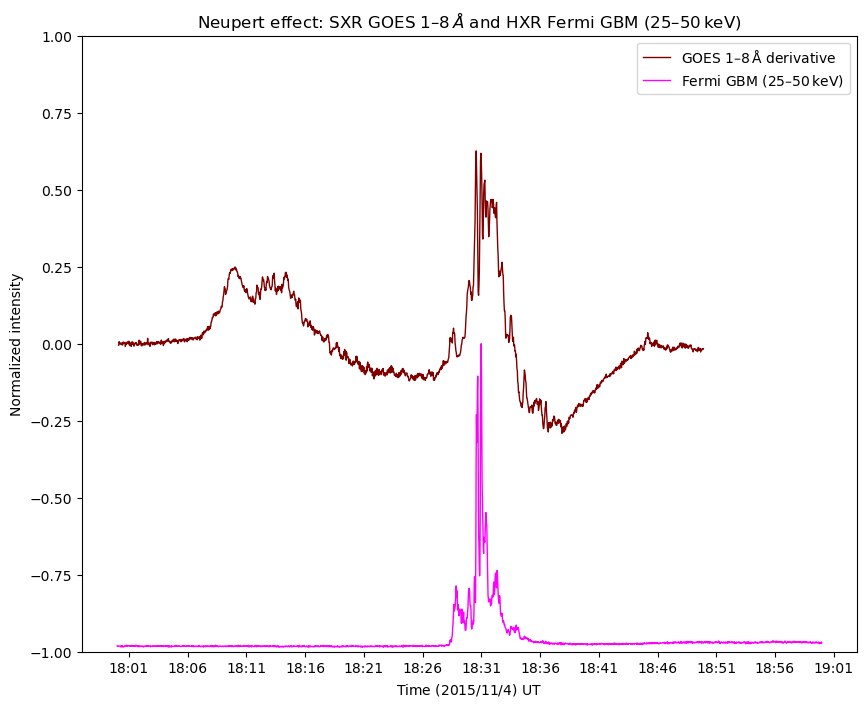

In [104]:
offset = 1
gbm = gbm_r['25-50 keV']
norm_gbm = gbm/gbm.max()
norm_gbm = norm_gbm - offset

plt.figure(figsize=(10,8))
plt.plot(smooth_goes_derv.index, smooth_goes_derv, c='maroon', lw=1, label=r'GOES $1–8\,\rm\AA$ derivative')
plt.plot(norm_gbm.index, norm_gbm, c='magenta', lw=1, label=r'Fermi GBM ($25–50\,\rm keV$)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

plt.ylim(-1, 1)
plt.xlabel(r'Time $(2015/11/4)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Neupert effect: SXR GOES $1–8\,\AA$ and HXR Fermi GBM ($25–50\,\rm keV$)')
plt.legend()
plt.show()

### $\color{red}{\text{4. EUI/HRIEUV intensity profiles (especially ribbon kernels)}} $

---

#### This will include working with the imaging data and extracting lightcurves from the images.

In [33]:
res = Fido.search(a.Time("2024-10-15 18:20", "2024-10-15 18:50"), 
                  a.Instrument.eui, a.soar.Product('eui-hrieuv174-image-short'),
                  a.Level(2))

In [2]:
p = '/home/zorzeus/sunpy/data'
files_eui = sorted(glob.glob(f'{p}/solo_L2_eui-hrieuv174*.fits'))
print(len(files_eui))

676


In [3]:
m = Map(files_eui[200]) # we check some properties

print(f"Image dimensions: {m.data.shape}")
print(f"Instrument: {m.instrument}")
print(f"Wavelength: {m.wavelength}")
print(f"Exposure time: {m.exposure_time}")
print(f"Pixel scale: {m.scale}")

Image dimensions: (2048, 2048)
Instrument: EUI
Wavelength: 174.0 Angstrom
Exposure time: 0.04 s
Pixel scale: SpatialPair(axis1=<Quantity 0.492 arcsec / pix>, axis2=<Quantity 0.492 arcsec / pix>)


In [ ]:
max_intensities = []
times = []

for file in files_eui:
    m = Map(file)
    max_intensities.append(np.max(m.data))
    times.append(m.date)

times_dt = [t.datetime for t in times]

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(times_dt, max_intensities, color='springgreen', linewidth=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Maximum Intensity')
plt.title('EUI maximum intensity evolution')
plt.xticks(rotation=45)
plt.show()

peak_idx = np.argmax(max_intensities) # we find peak time
peak_time = times[peak_idx]
print(f"Peak intensity at: {peak_time}")
print(f"Peak intensity value: {max_intensities[peak_idx]}")
print(f"File index: {peak_idx}")

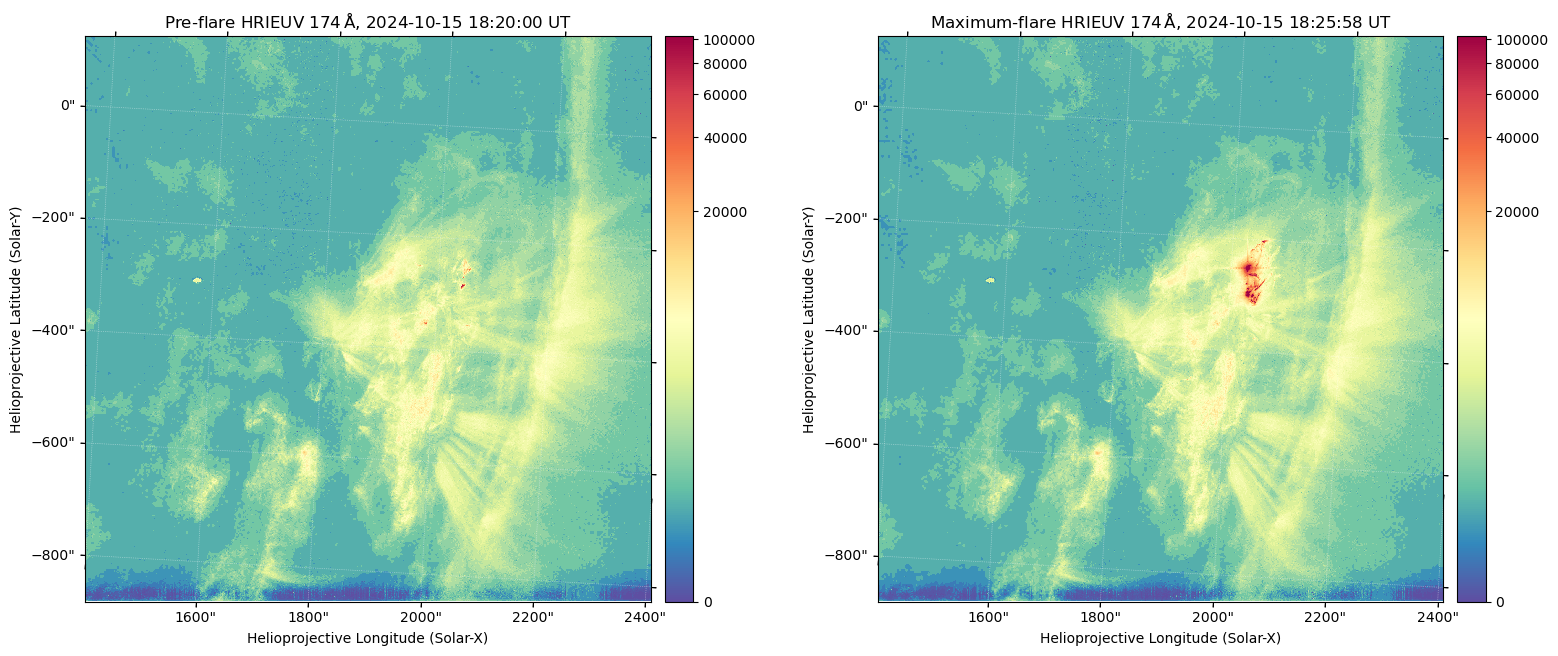

In [5]:
m0 = Map(files_eui[0])
m1 = Map(files_eui[135])

fig = plt.figure(figsize=(16, 6.5))

ax1 = fig.add_subplot(1,2,1, projection=m0)
m0.plot(axes=ax1, cmap='Spectral_r', vmax=np.max(m0))
cbar1 = plt.colorbar(ax1.images[0], ax=ax1, orientation='vertical', pad=0.02)
ax1.set_title(rf'Pre-flare HRIEUV $174\,\rm\AA$, {m0.date.strftime("%Y-%m-%d %H:%M:%S")} UT')

ax2 = fig.add_subplot(1,2,2, projection=m1)
m1.plot(axes=ax2, cmap='Spectral_r', vmax=np.max(m0)) 
cbar2 = plt.colorbar(ax2.images[0], ax=ax2, orientation='vertical', pad=0.02)
ax2.set_title(rf'Maximum-flare HRIEUV $174\,\rm\AA$, {m1.date.strftime("%Y-%m-%d %H:%M:%S")} UT')
plt.tight_layout()
plt.show()

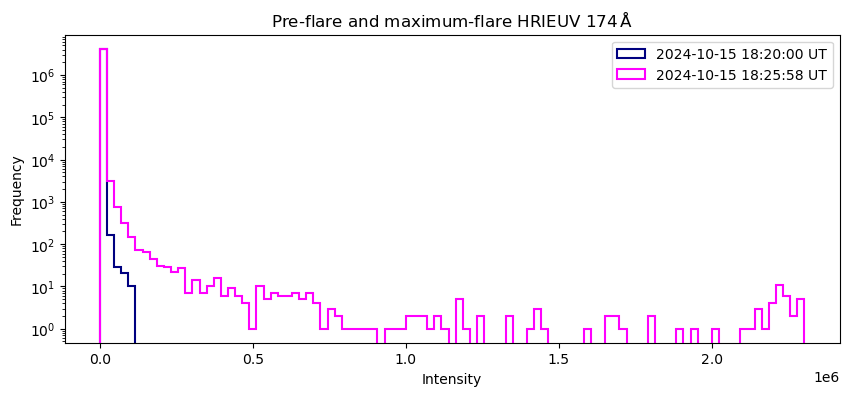

In [6]:
num_bins = 100
bins = np.linspace(m1.min(), m1.max(), num_bins)

hist0 = np.histogram(m0.data, bins=bins)
hist1 = np.histogram(m1.data, bins=bins)

plt.figure(figsize=(10,4))
plt.hist(m0.data.ravel(), bins=bins, color='navy', lw=1.5, label=rf'{m0.date.strftime("%Y-%m-%d %H:%M:%S")} UT', 
histtype='step', range=(np.min(m1), np.max(m1)))
plt.hist(m1.data.ravel(), bins=bins, color='magenta', lw=1.5, label=rf'{m1.date.strftime("%Y-%m-%d %H:%M:%S")} UT', 
         histtype='step',range=(np.min(m1), np.max(m1)))
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title(r'Pre-flare and maximum-flare HRIEUV $174\,\rm\AA$')
plt.legend()
plt.show()

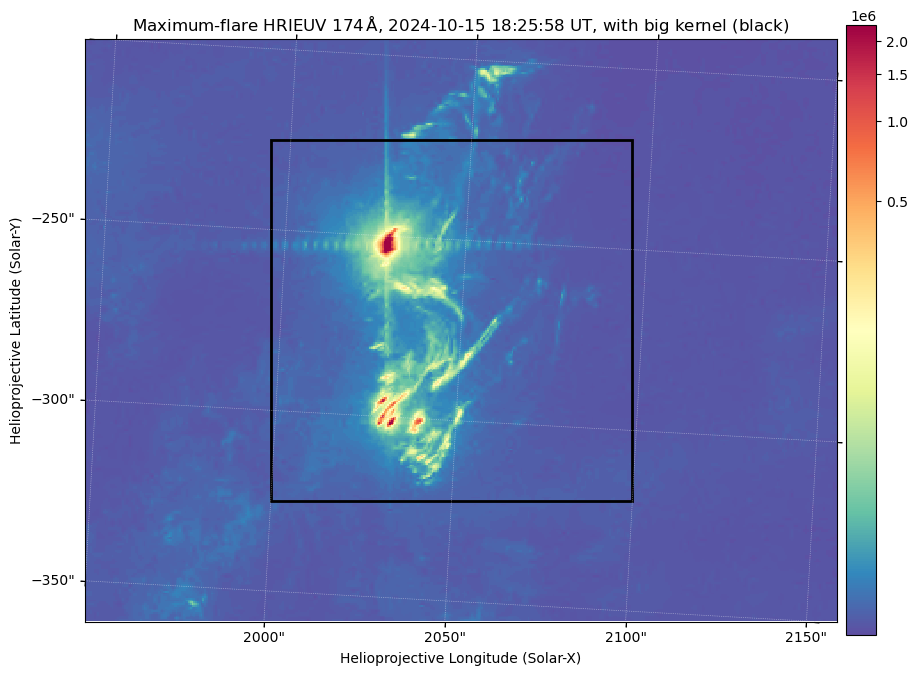

In [7]:
bl1= SkyCoord(1950*u.arcsec, -350*u.arcsec, frame=m1.coordinate_frame)
tr1 = SkyCoord(2150*u.arcsec, -200*u.arcsec, frame=m1.coordinate_frame)
sm1 = m1.submap(bottom_left=bl1, top_right=tr1)
levels = [25, 50, 75] * u.percent

fig = plt.figure(figsize=(10,7))
ax1 = plt.subplot(111, projection=sm1)  
sm1.plot(axes=ax1 ,cmap='Spectral_r')
cbar = plt.colorbar(ax1.images[0], ax=ax1, orientation='vertical', pad=0.01)

kernels = [SkyCoord(2000*u.arcsec, -325*u.arcsec, frame=sm1.coordinate_frame)]
           #SkyCoord(2100*u.arcsec, -200*u.arcsec, frame=sm1.coordinate_frame)]

cdelt_deg = abs(sm1.wcs.wcs.cdelt[0]) # deg / pixel
arcsec_per_pix = cdelt_deg * 3600 # arcsec / pixel
size_pix = 100 / arcsec_per_pix             

for corner in kernels:
    xpix, ypix = sm1.world_to_pixel(corner)
    rect = Rectangle((xpix.value, ypix.value),
                         size_pix, size_pix,
                         edgecolor='black', facecolor='none', lw=2,
                         transform=ax1.transData)
    ax1.add_patch(rect)

plt.title(rf'Maximum-flare HRIEUV $174\,\rm\AA$, {m1.date.strftime("%Y-%m-%d %H:%M:%S")} UT, with big kernel (black)') 
plt.tight_layout()
plt.show()

#### We notice that the grid isn't perfectly rectangular because we're working in helioprojective coordinates

#### on a spherical surface, and Solar Orbiter has a different viewing angle than Earth-based observations.

#### However, this shouldn't be problematic for QPP analysis, because we don't perform precise astrometry

#### and slight misalignments won't affect our intensity measurements significantly. 

---

#### We extract light curve from big kernel (black-colored rectangle on previous plot). 

In [163]:
bl1= SkyCoord(2000*u.arcsec, -325*u.arcsec, frame=m1.coordinate_frame)
tr1 = SkyCoord(2100*u.arcsec, -225*u.arcsec, frame=m1.coordinate_frame)
sm1 = m1.submap(bottom_left=bl1, top_right=tr1)

times1, flux1 = [], []

for fn in files_eui:
    m = Map(fn)
    times1.append(pd.Timestamp(m.date.iso))
    sub = m.submap(bottom_left=bl1, top_right=tr1)
    data = sub.data
    if np.isnan(data).all():y
        flux1.append(np.nan)
    else:
        flux1.append(np.nanmean(data))
    del m 

lc1= pd.Series(flux1, index=pd.DatetimeIndex(times1))
lc1_norm = lc1  / lc1.max()
lc1_norm.to_pickle("eui_big_kernel.pkl")

In [8]:
lc_big_kernel = pd.read_pickle('eui_big_kernel.pkl')

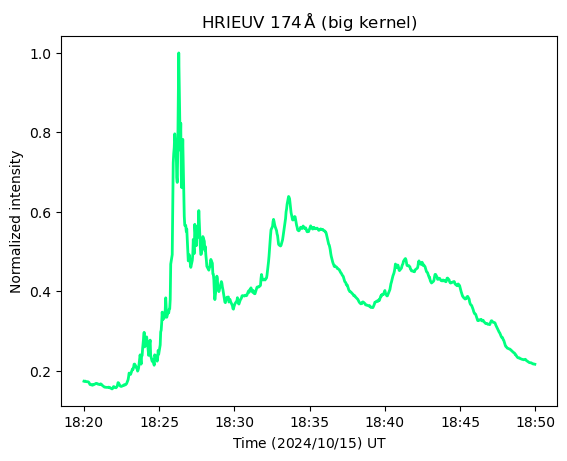

In [9]:
plt.figure(figsize=(12,5))
plt.plot(lc_big_kernel.index, lc_big_kernel, color='springgreen', lw=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'HRIEUV $174\,\rm\AA$ (big kernel)')
plt.show()

In [10]:
kernel_size = 30 # arcsec
step_size = 15 # arcsec (50% overlap)
lon_start, lon_end = 1970, 2130 # arcsec
lat_start, lat_end = -340, -180 # arcsec

longitude_range = np.arange(lon_start, lon_end - kernel_size, step_size)
latitude_range = np.arange(lat_start, lat_end - kernel_size, step_size)

print(f"Longitude positions: {len(longitude_range)}")
print(f"Latitude positions: {len(latitude_range)}")
print(f"Total kernels: {len(longitude_range) * len(latitude_range)}")

kernel_positions = []
kernel_names = []

for i, lon in enumerate(longitude_range):
    for j, lat in enumerate(latitude_range):
        bl_corner = SkyCoord(lon*u.arcsec, lat*u.arcsec, frame=m1.coordinate_frame)
        tr_corner = SkyCoord((lon + kernel_size)*u.arcsec, (lat + kernel_size)*u.arcsec, frame=m1.coordinate_frame)
        
        kernel_positions.append((bl_corner, tr_corner))
        kernel_names.append(f"kernel_{i:02d}_{j:02d}")

print(f"Created {len(kernel_positions)} overlapping kernels")

Longitude positions: 9
Latitude positions: 9
Total kernels: 81
Created 81 overlapping kernels


In [55]:
def extract_lightcurves(files_eui, kernel_positions, kernel_names, output_dir="eui_kernel_lightcurves"):

    os.makedirs(output_dir, exist_ok=True)
    print(f"Extracting {len(kernel_names)} kernels...")
    print(f"Output directory: {output_dir}")
    
    for idx, ((bl_corner, tr_corner), name) in enumerate(zip(kernel_positions, kernel_names)):
        print(f"Processing ({idx+1}/{len(kernel_names)})...")
        times = []
        flux = []
        for file_idx, fn in enumerate(files_eui):
            m = Map(fn)
            times.append(pd.Timestamp(m.date.iso))
            sub = m.submap(bottom_left=bl_corner, top_right=tr_corner)
            data = sub.data
            if np.isnan(data).all():
                flux.append(np.nan)
            else:
                flux.append(np.nanmean(data))
            del m
            if (file_idx + 1) % 100 == 0:
                print(f"Processed {file_idx+1}/{len(files_eui)} images!")
        
        lc = pd.Series(flux, index=pd.DatetimeIndex(times))
        lc_norm = lc / lc.max()
        filename = os.path.join(output_dir, f"{name}.pkl")
        lc_norm.to_pickle(filename)
        print(f"Saved {name}.pkl")
    
    print("="*60)
    print(f"Successfully saved {len(kernel_names)} lightcurves to {output_dir}/")

#### The light curve extraction and processing procedures turned out to be quite time-consuming when 

#### performed on a local machine. In order to speed up the analysis and handle larger datasets more

#### efficiently, we transferred the workflow to a remote server with greater computational capacity.

#### Alternatives to that would be to utilize numba's features or fully vectorized approach.

In [221]:
lightcurve_dir = "eui_lightcurves"
lc_files = sorted(glob.glob(f"{lightcurve_dir}/kernel_*.pkl"))

eui_lcs = {}
for file in lc_files:
    kernel_name = os.path.basename(file).replace('.pkl', '')
    eui_lcs[kernel_name] = pd.read_pickle(file)

#### We'll create short animation on how these various kernel light curves evolve over time. 

In [246]:
def create_lightcurve_movie(output_name='eui_lightcurves.gif', 
                           fps=2, interval=500, show_legend=True, writer='pillow'):
    
    print("="*60)
    print("Creating animation")
    print("="*60)
    print(f"Found {len(eui_lcs)} kernel lightcurves!")
    
    if not eui_lcs:
        print("Error: No lightcurves found!")
        return
    
    kernel_names = list(eui_lcs.keys())
    total_frames = len(kernel_names)
    
    print(f"Animation will have {total_frames} frames (one per kernel)")
    print(f"FPS: {fps}, Interval: {interval}ms")
    print("-"*60)
    
    try:
        print("Setting up figure...")
        fig, ax = plt.subplots(figsize=(12, 5))
        
        def animate(frame):
            if frame % max(1, total_frames // 10) == 0:
                progress = (frame / total_frames) * 100
                print(f"Rendering frame {frame}/{total_frames} ({progress:.1f}%)")
            ax.clear()

            current_kernel = kernel_names[frame]
            lc = eui_lcs[current_kernel]
            parts = current_kernel.split('_')
            i, j = int(parts[1]), int(parts[2])
            lon_start, lat_start = 1970, -340
            step_size = 15
            kernel_size = 30
            
            lon = lon_start + i * step_size
            lat = lat_start + j * step_size
            lc_normalized = (lc - lc.min()) / (lc.max() - lc.min())
            
            ax.plot(lc.index, lc_normalized, color='springgreen', linewidth=2)
            ax.set_xlabel('Time (2024/10/15) UT')
            ax.set_ylabel('Normalized intensity')
            ax.set_title(f'HRIEUV extracted from kernel [longitude ({lon}", {lon+kernel_size}"), latitude ({lat}", {lat+kernel_size}")]')
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
        
        print("Starting animation creation...")
        ani = animation.FuncAnimation(fig, animate, frames=total_frames, interval=interval, repeat=True)
        print("Saving animation file...")
        
        if writer == 'html':
            ani.save(output_name, writer='html', fps=fps)
        elif writer == 'pillow':
            ani.save(output_name, writer='pillow', fps=fps)
        else:
            print(f"Error: Unknown writer '{writer}'. Use 'html' or 'pillow'")
            return
        
        plt.close(fig)
        
        print("Animation saved successfully!")
        if os.path.exists(output_name):
            file_size = os.path.getsize(output_name) / (1024*1024)
            print(f"File size: {file_size:.2f} MB")

    except Exception as e:
        print(f"Error creating animation: {e}")
        return

In [247]:
create_lightcurve_movie()

2025-07-31 21:37:13 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.PillowWriter'>


Creating animation
Found 81 kernel lightcurves!
Animation will have 81 frames (one per kernel)
FPS: 2, Interval: 500ms
------------------------------------------------------------
Setting up figure...
Starting animation creation...
Saving animation file...
Rendering frame 0/81 (0.0%)
Rendering frame 0/81 (0.0%)
Rendering frame 8/81 (9.9%)
Rendering frame 16/81 (19.8%)
Rendering frame 24/81 (29.6%)
Rendering frame 32/81 (39.5%)
Rendering frame 40/81 (49.4%)
Rendering frame 48/81 (59.3%)
Rendering frame 56/81 (69.1%)
Rendering frame 64/81 (79.0%)
Rendering frame 72/81 (88.9%)
Rendering frame 80/81 (98.8%)
Animation saved successfully!
File size: 1.78 MB


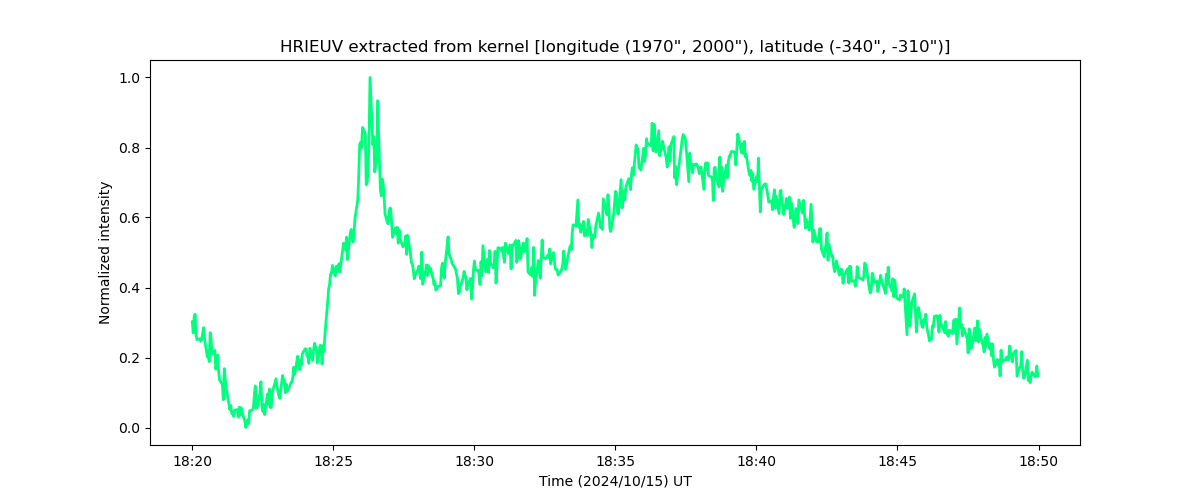

### $\color{red}{\text{6. Time correction \& HRIEUV kernel selection.}} $

---

#### Solar Orbiter is closer to the Sun, there is a time shift between Earth (i.e. GOES/Fermi  and STIX/EUI) of 

#### around 281 seconds. Also, since we generated EUV light curves from multiple kernels, we need to decide on

#### on which one is best fitted to look for periodicity.

In [204]:
# we shift Solar Orbiter data to Earth time reference
stix_lcs_corrected = {}
for band_name, lc in stix_lcs.items():
    corrected_times = lc.index + pd.Timedelta(seconds=281)
    stix_lcs_corrected[band_name] = pd.Series(lc.values, index=corrected_times,
                                              name=f"{band_name} (corrected)")

stix_lcs_corrected = {band: lc/lc.max() for band, lc in stix_lcs_corrected.items()} # normalization

eui_lcs_corrected = {kernel: lc.shift(freq='281S') for kernel, lc in eui_lcs.items()}
eui_lcs_corrected = {kernel: lc/lc.max() for kernel, lc in eui_lcs.items()}

# we rename some of our light curves
goes_lc = smooth_goes_derv
fermi_lc = norm_gbm

In [205]:
start_time = pd.Timestamp('2024-10-15 18:24:00')
end_time = pd.Timestamp('2024-10-15 18:44:00')

stix_lcs_trimmed = {}
for band, lc in stix_lcs_corrected.items():
    stix_lcs_trimmed[band] = lc[(lc.index >= start_time) & (lc.index <= end_time)]

eui_lcs_trimmed = {}
for kernel, lc in eui_lcs_corrected.items():
    eui_lcs_trimmed[kernel] = lc[(lc.index >= start_time) & (lc.index <= end_time)]

goes_lc_trimmed = goes_lc[(goes_lc.index >= start_time) & (goes_lc.index <= end_time)]
fermi_lc_trimmed = fermi_lc[(fermi_lc.index >= start_time) & (fermi_lc.index <= end_time)]

print("Time ranges after trimming:")
print(f"STIX: {stix_lcs_trimmed['25-50 keV'].index[0]} to {stix_lcs_trimmed['25-50 keV'].index[-1]}")
print(f"EUI: {list(eui_lcs_trimmed.values())[0].index[0]} to {list(eui_lcs_trimmed.values())[0].index[-1]}")
print(f"GOES: {goes_lc_trimmed.index[0]} to {goes_lc_trimmed.index[-1]}")
print(f"Fermi: {fermi_lc_trimmed.index[0]} to {fermi_lc_trimmed.index[-1]}")

Time ranges after trimming:
STIX: 2024-10-15 18:24:00.665000 to 2024-10-15 18:43:59.915000
EUI: 2024-10-15 18:24:00.312000 to 2024-10-15 18:43:54.247000
GOES: 2024-10-15 18:24:00 to 2024-10-15 18:44:00
Fermi: 2024-10-15 18:24:00 to 2024-10-15 18:44:00


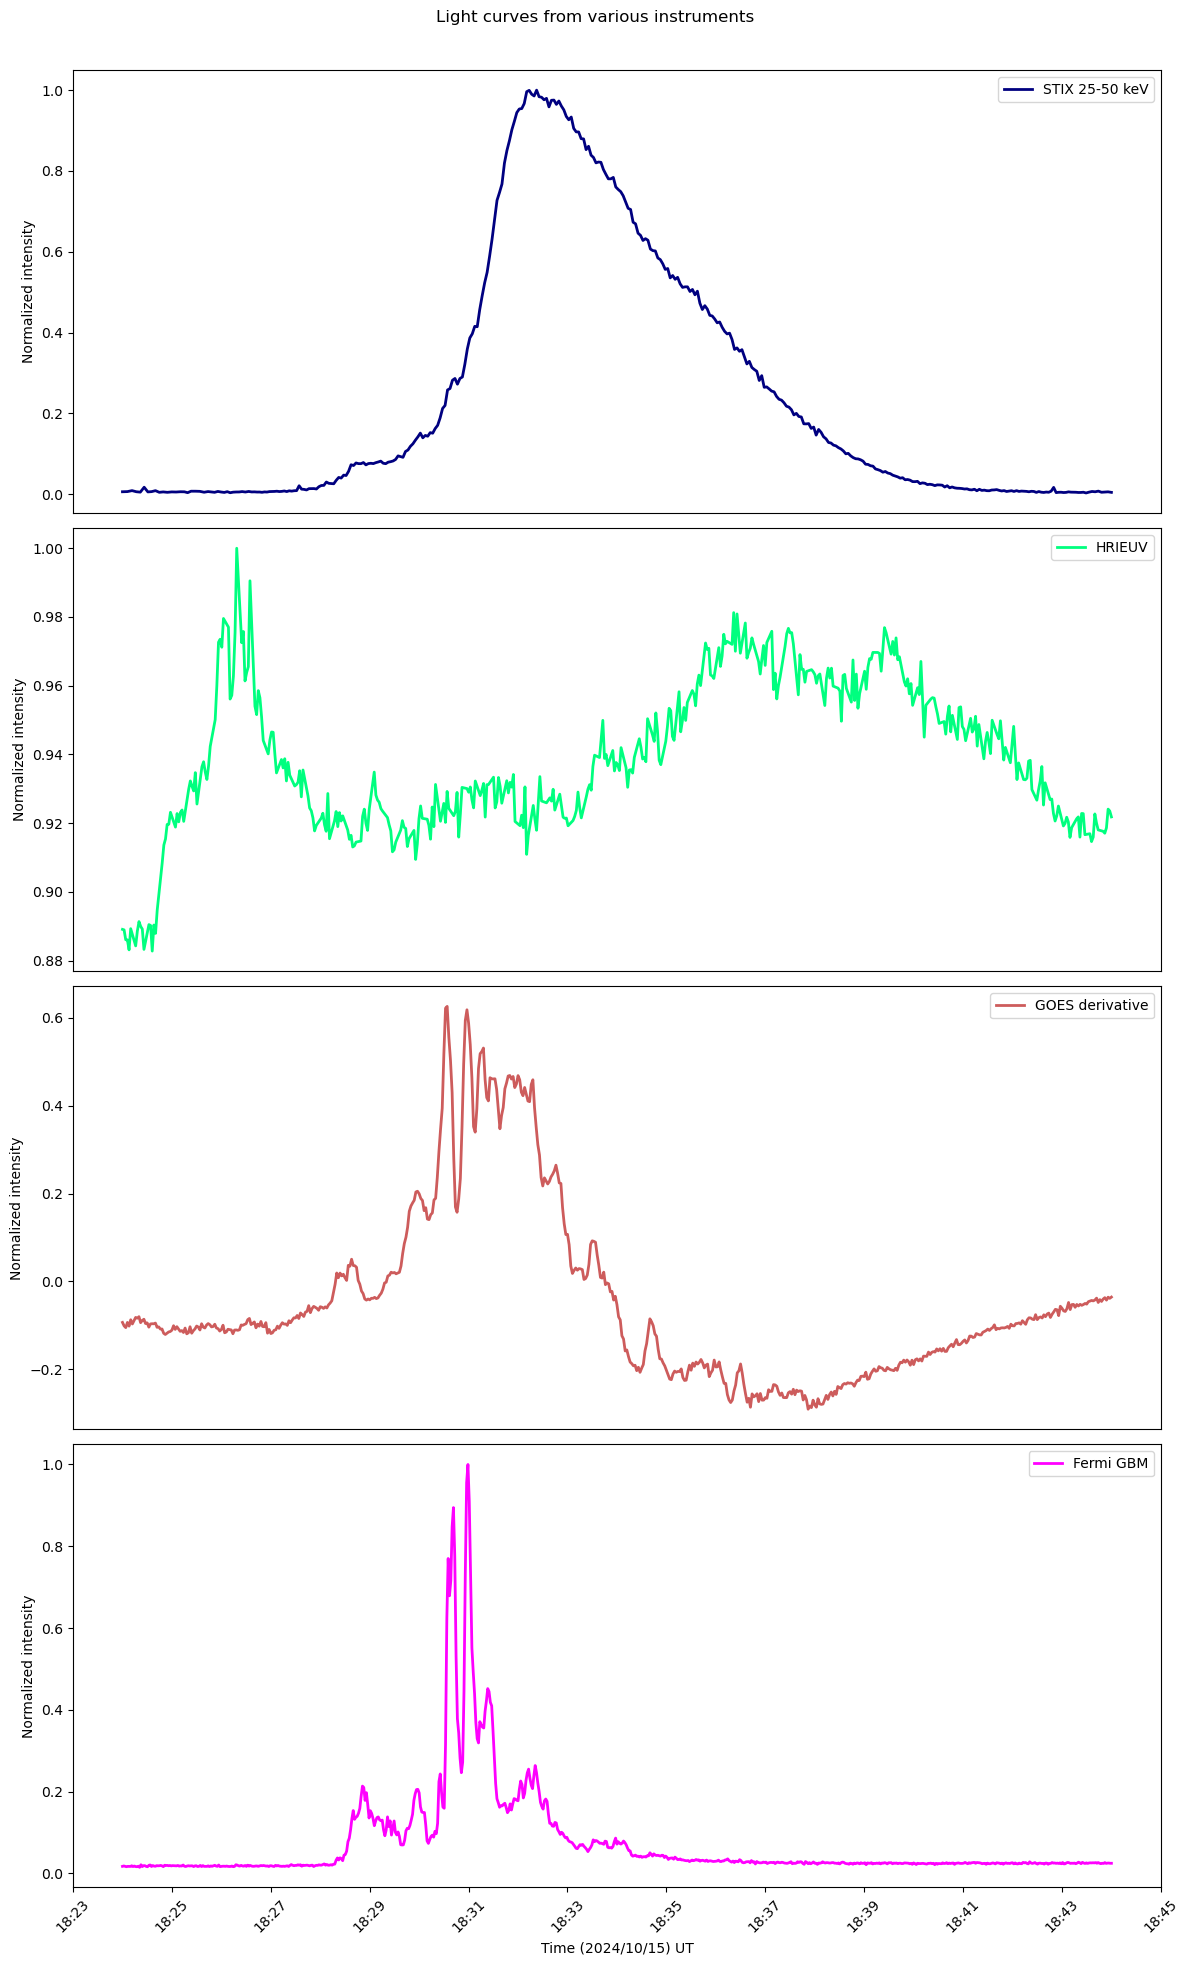

In [250]:
plt.figure(figsize=(12,20))
plt.subplot(411)
plt.plot(stix_lcs_trimmed['25-50 keV'].index, stix_lcs_trimmed['25-50 keV'], color='navy', linewidth=2, label='STIX 25-50 keV')
plt.ylabel('Normalized intensity')
plt.xticks([])
plt.legend()
plt.subplot(412)
plt.plot(eui_lcs_trimmed['kernel_00_00'].index, eui_lcs_trimmed['kernel_00_00'], color='springgreen', linewidth=2, label='HRIEUV')
plt.ylabel('Normalized intensity')
plt.xticks([])
plt.legend()
plt.subplot(413)
plt.plot(goes_lc_trimmed.index, goes_lc_trimmed, color='indianred', linewidth=2, label='GOES derivative')
plt.ylabel('Normalized intensity')
plt.xticks([])
plt.legend()
plt.subplot(414)
plt.plot(fermi_lc_trimmed.index, fermi_lc_trimmed, color='magenta', linewidth=2, label='Fermi GBM')
plt.ylabel('Normalized intensity')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
plt.xlabel('Time (2024/10/15) UT')
plt.xticks(rotation=45)
plt.suptitle('Light curves from various instruments')
    
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [209]:
def perform_correlation_analysis(stix_lcs_trimmed, eui_lcs_trimmed, goes_lc_trimmed, fermi_lc_trimmed):
    ref_time = stix_lcs_trimmed['25-50 keV'].index

    stix_interp = stix_lcs_trimmed['25-50 keV'].reindex(ref_time, method='nearest')
    eui_interp = eui_lcs_trimmed['kernel_00_00'].reindex(ref_time, method='nearest')
    goes_interp = goes_lc_trimmed.reindex(ref_time, method='nearest')
    fermi_interp = fermi_lc_trimmed.reindex(ref_time, method='nearest')

    valid_mask = ~(stix_interp.isna() | eui_interp.isna() | goes_interp.isna() | fermi_interp.isna())
    stix_clean = stix_interp[valid_mask]
    eui_clean = eui_interp[valid_mask]
    goes_clean = goes_interp[valid_mask]
    fermi_clean = fermi_interp[valid_mask]

    df = pd.DataFrame({
        'STIX 25-50 keV': stix_clean,
        'EUI kernel_00_00': eui_clean,
        'GOES derivative': goes_clean,
        'Fermi/GBM': fermi_clean})

    corr_matrix = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)
    pval_matrix = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)

    for col1 in df.columns:
        for col2 in df.columns:
            corr, pval = pearsonr(df[col1], df[col2])
            corr_matrix.loc[col1, col2] = corr
            pval_matrix.loc[col1, col2] = pval

    def format_entry(corr, pval):
        if np.isnan(corr): return ""
        if pval < 0.001:
            sig = "***"
        elif pval < 0.01:
            sig = "**"
        elif pval < 0.05:
            sig = "*"
        else:
            sig = ""
        return f"{corr:.3f} {sig}"

    formatted = corr_matrix.copy()
    for col1 in df.columns:
        for col2 in df.columns:
            formatted.loc[col1, col2] = format_entry(corr_matrix.loc[col1, col2], pval_matrix.loc[col1, col2])

    print("\n📊 Pearson Correlation Matrix (with significance):\n")
    print(formatted.to_string())

    return corr_matrix, pval_matrix, formatted

In [211]:
perform_correlation_analysis(stix_lcs_trimmed, eui_lcs_trimmed, goes_lc_trimmed, fermi_lc_trimmed)


📊 Pearson Correlation Matrix (with significance):

                 STIX 25-50 keV EUI kernel_00_00 GOES derivative   Fermi/GBM
STIX 25-50 keV        1.000 ***          -0.056        0.437 ***   0.292 ***
EUI kernel_00_00        -0.056         1.000 ***      -0.548 ***  -0.275 ***
GOES derivative       0.437 ***       -0.548 ***       1.000 ***   0.760 ***
Fermi/GBM             0.292 ***       -0.275 ***       0.760 ***   1.000 ***


(                  STIX 25-50 keV  EUI kernel_00_00  GOES derivative  Fermi/GBM
 STIX 25-50 keV          1.000000         -0.056297         0.436523   0.291564
 EUI kernel_00_00       -0.056297          1.000000        -0.548265  -0.275419
 GOES derivative         0.436523         -0.548265         1.000000   0.760350
 Fermi/GBM               0.291564         -0.275419         0.760350   1.000000,
                   STIX 25-50 keV  EUI kernel_00_00  GOES derivative  \
 STIX 25-50 keV      0.000000e+00      2.730241e-01     3.710247e-19   
 EUI kernel_00_00    2.730241e-01      0.000000e+00     2.798548e-31   
 GOES derivative     3.710247e-19      2.798548e-31     0.000000e+00   
 Fermi/GBM           6.676343e-09      4.646122e-08     5.027445e-73   
 
                      Fermi/GBM  
 STIX 25-50 keV    6.676343e-09  
 EUI kernel_00_00  4.646122e-08  
 GOES derivative   5.027445e-73  
 Fermi/GBM         0.000000e+00  ,
                  STIX 25-50 keV EUI kernel_00_00 GOES derivative 

### $\color{red}{\text{7. Determination of the periodicities - WAVELET ANALYSIS}} $

---

#### Here, we perform detailed wavelet analysis of multi-wavelength light curves. 